In [10]:
import pandas as pd
import matplotlib.pyplot as plt

In [9]:
df = pd.read_csv("supermarket_sales.csv")

In [5]:
df.columns


Index(['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender',
       'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Total', 'Date',
       'Time', 'Payment', 'cogs', 'gross margin percentage', 'gross income',
       'Rating'],
      dtype='str')

In [7]:
df.isnull().sum()

Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Total                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64

In [11]:
df.columns[df.isnull().all()].tolist()

[]

In [12]:
df.columns[df.isnull().any()].tolist()

[]

In [14]:
df.dtypes

Invoice ID                     str
Branch                         str
City                           str
Customer type                  str
Gender                         str
Product line                   str
Unit price                 float64
Quantity                     int64
Tax 5%                     float64
Total                      float64
Date                           str
Time                           str
Payment                        str
cogs                       float64
gross margin percentage    float64
gross income               float64
Rating                     float64
dtype: object

In [18]:
df['Date']=pd.to_datetime(df['Date'])

In [23]:
df["Hour"] = pd.to_datetime(df["Time"], format = "%H:%M").dt.hour

In [21]:
df["Time"] = pd.to_datetime(df["Time"], format = "%H:%M").dt.time

In [5]:
df["Gross_margin"] = df["gross income"]/df["Total"]*100

In [17]:
print(df.groupby("Branch")["Total"].sum())
print(df.groupby("Branch")["Quantity"].count())

Branch
A    106200.3705
B    106197.6720
C    110568.7065
Name: Total, dtype: float64
Branch
A    340
B    332
C    328
Name: Quantity, dtype: int64


In [16]:
print("sum according to the total")
print(df.groupby("Product line")["Total"].sum())
print("count according to the total")
print(df.groupby("Product line")["Total"].count())

sum according to the total
Product line
Electronic accessories    54337.5315
Fashion accessories       54305.8950
Food and beverages        56144.8440
Health and beauty         49193.7390
Home and lifestyle        53861.9130
Sports and travel         55122.8265
Name: Total, dtype: float64
count according to the total
Product line
Electronic accessories    170
Fashion accessories       178
Food and beverages        174
Health and beauty         152
Home and lifestyle        160
Sports and travel         166
Name: Total, dtype: int64


In [27]:
df.groupby("Hour")["Total"].count().sort_values(ascending = False)

Hour
19    113
13    103
15    102
10    101
18     93
11     90
12     89
14     83
16     77
20     75
17     74
Name: Total, dtype: int64

In [28]:
product_sales = df.groupby("Product line")["Total"].sum().sort_values(ascending=False)
print("en cox satilan mehsul kateqoriyasi")
print(product_sales.head(1))
print("en az satilan mehsul kateqoriyasi")
print(product_sales.tail(1))

en cox satilan mehsul kateqoriyasi
Product line
Food and beverages    56144.844
Name: Total, dtype: float64
en az satilan mehsul kateqoriyasi
Product line
Health and beauty    49193.739
Name: Total, dtype: float64


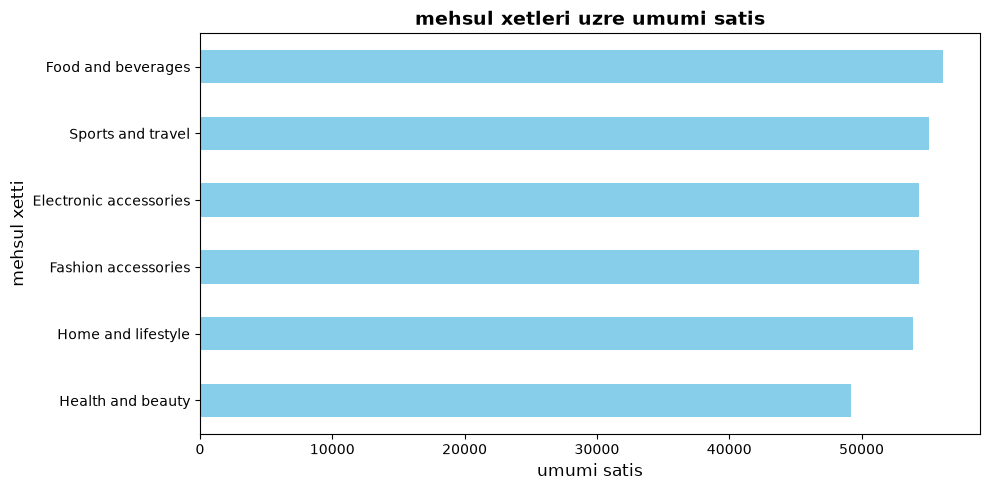

In [34]:
plt.figure(figsize=(10, 5))

df.groupby('Product line')['Total'].sum().sort_values().plot(kind='barh', color='skyblue')

plt.title('mehsul xetleri uzre umumi satis', fontsize=14, fontweight='bold')
plt.xlabel('umumi satis', fontsize=12)
plt.ylabel('mehsul xetti', fontsize=12)
plt.tight_layout()
plt.show()

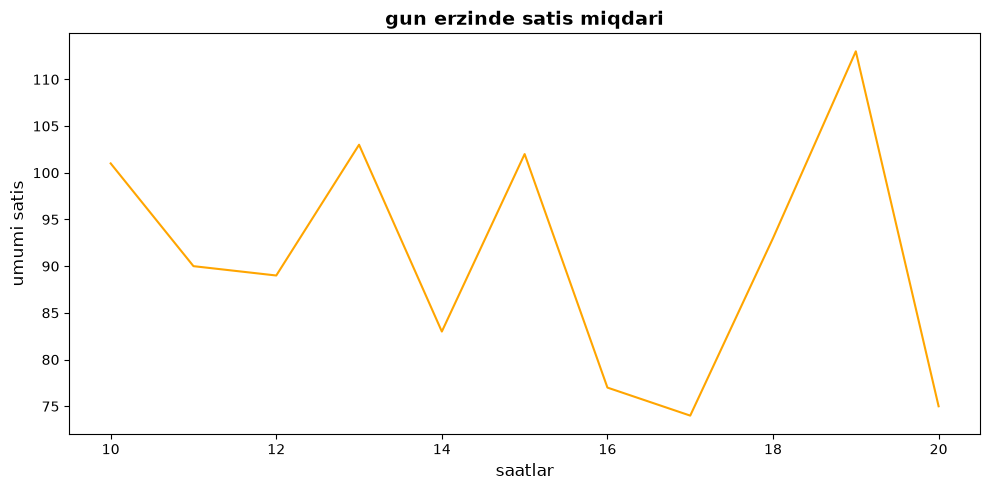

In [43]:
plt.figure(figsize=(10, 5))
df.groupby("Hour")["Quantity"].count().sort_index().plot(kind="line", color= "Orange")
plt.title('gun erzinde satis miqdari', fontsize=14, fontweight='bold')
plt.xlabel('saatlar', fontsize=12)
plt.ylabel('umumi satis', fontsize=12)
plt.tight_layout()
plt.show()

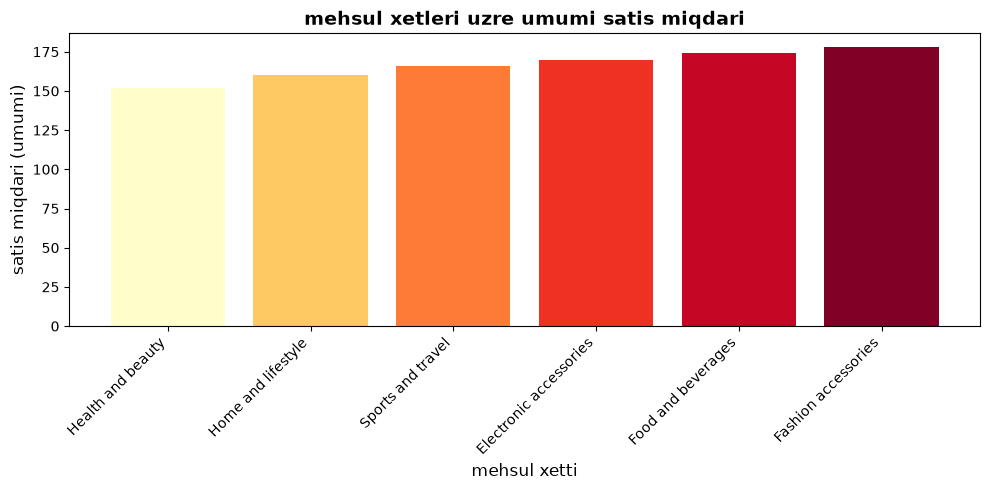

In [59]:
plt.figure(figsize=(10, 5))
sales = df.groupby("Product line")["Quantity"].count().sort_values()
norm = plt.Normalize(sales.min(), sales.max())
colors = plt.cm.YlOrRd(norm(sales.values))
plt.bar(sales.index, sales.values, color = colors)

plt.title('mehsul xetleri uzre umumi satis miqdari', fontsize=14, fontweight='bold')
plt.xlabel('mehsul xetti', fontsize=12)
plt.ylabel('satis miqdari (umumi)', fontsize=12)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

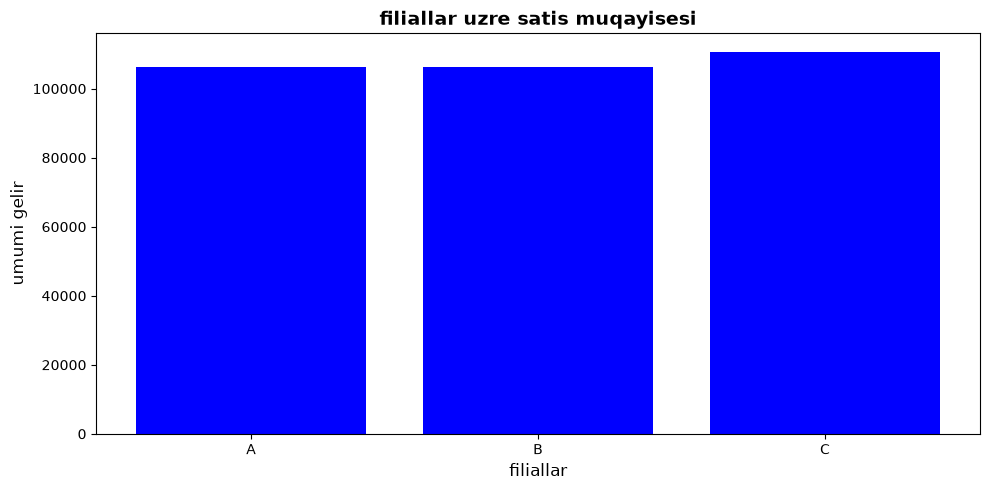

In [66]:
plt.figure(figsize=(10, 5))
branch_sales = df.groupby("Branch")["Total"].sum()
norm = plt.Normalize(vmin=0, vmax = branch_sales.max())
plt.bar(branch_sales.index, branch_sales.values, color="blue")

plt.title('filiallar uzre satis muqayisesi', fontsize=14, fontweight='bold')
plt.xlabel('filiallar', fontsize=12)
plt.ylabel('umumi gelir', fontsize=12)

plt.tight_layout()
plt.show()

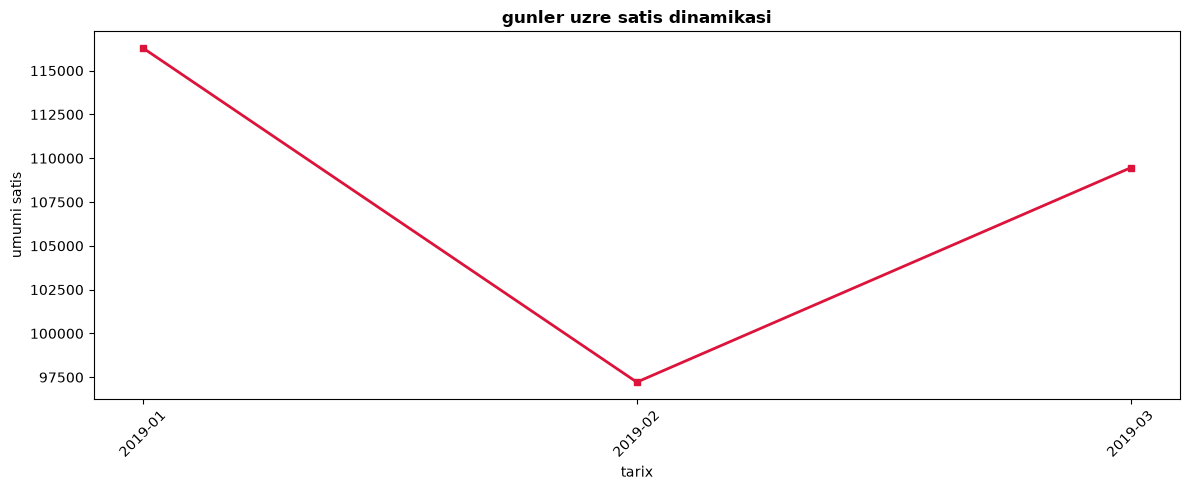

In [21]:
plt.figure(figsize=(12, 5))
monthly_sales = df.groupby("Date")["Total"].sum().sort_index()
x_labels = monthly_sales.index.astype(str)
plt.plot(x_labels, daily_sales.values, color='crimson', linewidth=2, marker='s', markersize=4)

plt.title("gunler uzre satis dinamikasi", fontweight="bold")
plt.xlabel("tarix")
plt.ylabel("umumi satis")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

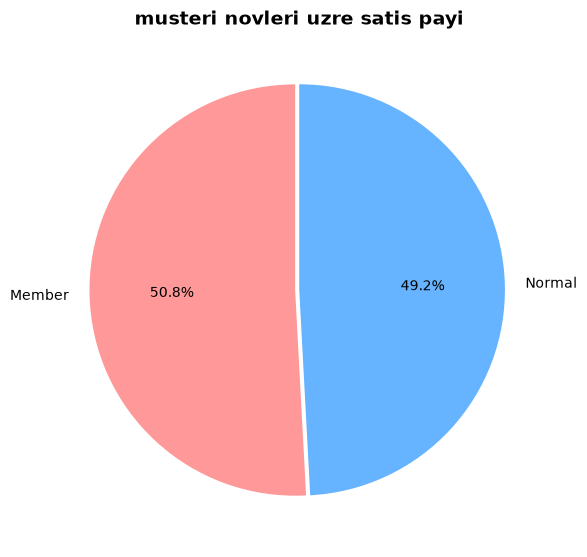

In [33]:
plt.figure(figsize=(6, 6))
customer_sales = df.groupby("Customer type")["Total"].sum()
plt.pie(customer_sales.values, 
        labels=customer_sales.index, 
        autopct='%1.1f%%', 
        colors=['#ff9999', '#66b3ff'], startangle=90, explode=(0.02, 0))
    
plt.title('musteri novleri uzre satis payi', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()